In [1]:
# Import Libraries
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.gen_plots import sgt_csv_to_dataframe, sgt_spider_plot

In [2]:
# Read data from files
allowed_ext = ".csv"
csv_dir_path = "1um/"
pdf_file = "gt_analysis.pdf"
plt_figs = []

all_sheets = sgt_csv_to_dataframe(csv_dir_path, delimiter=",")
print(all_sheets.keys())

dict_keys(['ARImGr0S1_1', 'ARImGr0S1_2', 'ARImGr0S1_3', 'ARImGr0S1_4', 'ARImGr0S2_1', 'ARImGr0S2_2', 'ARImGr0S2_3', 'ARImGr0S2_4', 'ARImGr0S3_1', 'ARImGr0S3_2', 'ARImGr0S3_3', 'ARImGr0S3_4', 'ARImGr0S4_1', 'ARImGr0S4_2', 'ARImGr0S4_3', 'ARImGr0S4_4', 'ARImGr0S5_1', 'ARImGr0S5_2', 'ARImGr0S5_3', 'ARImGr0S5_4', 'ARImGr0S6_1', 'ARImGr0S6_2', 'ARImGr0S6_3', 'ARImGr0S6_4', 'ARImGr0S7_1', 'ARImGr0S7_2', 'ARImGr0S7_3', 'ARImGr0S7_4', 'ARImGr0S8_1', 'ARImGr0S8_2', 'ARImGr0S8_3', 'ARImGr0S8_4', 'ARImGr0S9_1', 'ARImGr0S9_2', 'ARImGr0S9_3', 'ARImGr0S9_4'])


In [11]:
# Filter SGT parameters
materials = ['ARImGr0S1', 'ARImGr0S2', 'ARImGr0S3', 'ARImGr0S4', "ARImGr0S5", "ARImGr0S6", "ARImGr0S7", "ARImGr0S8", "ARImGr0S9"]
# parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']
parameters = ['AD', 'GD', 'BC', 'CC', 'EC']
val_cols = ["value-1", "value-2", "value-3", "value-4"]


In [4]:
all_sheets['ARImGr0S1_1']

,parameter,value
0,Number of nodes,1391.00000
1,Number of edges,1777.00000
2,Average edge angle (degrees),160.49700
3,Median edge angle (degrees),85.42600
4,Average degree,2.55500
5,Network diameter,64.00000
6,Graph density,0.00184
7,Global efficiency,0.05397
8,Assortativity coefficient,-0.06910
9,Average clustering coefficient,0.03091


In [5]:
# Combine the 4 sections for each material into 1 DataFrame (to be averaged)

all_avg_dfs = {}

for mat_label in materials:
    avg_df = None
    i = 1
    for key, df in all_sheets.items():
        if key.startswith(mat_label):
            temp_df = df.copy()
            temp_df.rename(columns={'value': f'value-{i}'}, inplace=True)
            if avg_df is None:
                avg_df = temp_df
            else:
                avg_df = pd.merge(avg_df, temp_df, on='parameter', how='inner')
            i += 1

    if avg_df is not None:
        avg_df.insert(0, "Material", mat_label)
        all_avg_dfs[mat_label] = avg_df

In [6]:
# Combine the 3 sections for each material into 1 DataFrame (to be averaged)

df_sec_1 = pd.concat([all_avg_dfs['ARImGr0S1'], all_avg_dfs['ARImGr0S2'], all_avg_dfs['ARImGr0S3']], ignore_index=True)
df_sec_2 = pd.concat([all_avg_dfs['ARImGr0S4'], all_avg_dfs['ARImGr0S5'], all_avg_dfs['ARImGr0S6']], ignore_index=True)
df_sec_3 = pd.concat([all_avg_dfs['ARImGr0S7'], all_avg_dfs['ARImGr0S8'], all_avg_dfs['ARImGr0S9']], ignore_index=True)

In [7]:
# Compute averages

avg_df = df_sec_1.groupby("parameter", as_index=False)[val_cols].mean()
avg_df.insert(0, "Material", "ARImGRS1S2S3")
all_avg_dfs['ARImGRS1S2S3'] = avg_df

avg_df = df_sec_2.groupby("parameter", as_index=False)[val_cols].mean()
avg_df.insert(0, "Material", "ARImGRS4S5S6")
all_avg_dfs['ARImGRS4S5S6'] = avg_df

avg_df = df_sec_3.groupby("parameter", as_index=False)[val_cols].mean()
avg_df.insert(0, "Material", "ARImGRS7S8S9")
all_avg_dfs['ARImGRS7S8S9'] = avg_df


In [8]:
all_avg_dfs["ARImGRS1S2S3"]

,Material,parameter,value-1,value-2,value-3,value-4
0,ARImGRS1S2S3,Assortativity coefficient,-0.112507,-0.083677,-0.114097,-0.078823
1,ARImGRS1S2S3,Average betweenness centrality,0.026763,0.021307,0.022920,0.022113
2,ARImGRS1S2S3,Average closeness centrality,0.048900,0.047657,0.042780,0.038780
3,ARImGRS1S2S3,Average clustering coefficient,0.029940,0.022380,0.021373,0.022703
4,ARImGRS1S2S3,Average degree,2.458420,2.564850,2.468267,2.497287
5,ARImGRS1S2S3,Average edge angle (degrees),165.200000,158.315000,152.955000,157.707333
6,ARImGRS1S2S3,Average eigenvector centrality,0.011083,0.009203,0.006680,0.005733
7,ARImGRS1S2S3,Global efficiency,0.067245,0.069480,0.062410,0.057170
8,ARImGRS1S2S3,Graph density,0.003377,0.002753,0.002467,0.002140
9,ARImGRS1S2S3,Median edge angle (degrees),146.476667,85.074333,80.476667,83.123333


In [9]:
lst_compare = [
    ['ARImGr0S1', 'ARImGr0S4'],
    ['ARImGr0S2', 'ARImGr0S5'],
    ['ARImGr0S3', 'ARImGr0S6'],
    ['ARImGr0S4', 'ARImGr0S7'],
    ['ARImGr0S5', 'ARImGr0S8'],
    ['ARImGr0S6', 'ARImGr0S9'],
    #['ARImGRS1S2S3', 'ARImGRS4S5S6'],
    #['ARImGRS4S5S6', 'ARImGRS7S8S9']
]
all_avg_dfs['ARImGr0S1']

,Material,parameter,value-1,value-2,value-3,value-4
0,ARImGr0S1,Number of nodes,1391.00000,1356.00000,1112.00000,1500.00000
1,ARImGr0S1,Number of edges,1777.00000,1754.00000,1395.00000,2052.00000
2,ARImGr0S1,Average edge angle (degrees),160.49700,165.60800,158.31000,153.17400
3,ARImGr0S1,Median edge angle (degrees),85.42600,87.27400,84.80600,84.91800
4,ARImGr0S1,Average degree,2.55500,2.58702,2.50899,2.73600
5,ARImGr0S1,Network diameter,64.00000,61.00000,58.00000,67.00000
6,ARImGr0S1,Graph density,0.00184,0.00191,0.00226,0.00183
7,ARImGr0S1,Global efficiency,0.05397,0.05630,0.05991,0.05149
8,ARImGr0S1,Assortativity coefficient,-0.06910,-0.09637,-0.11493,0.05715
9,ARImGr0S1,Average clustering coefficient,0.03091,0.02706,0.02233,0.03429


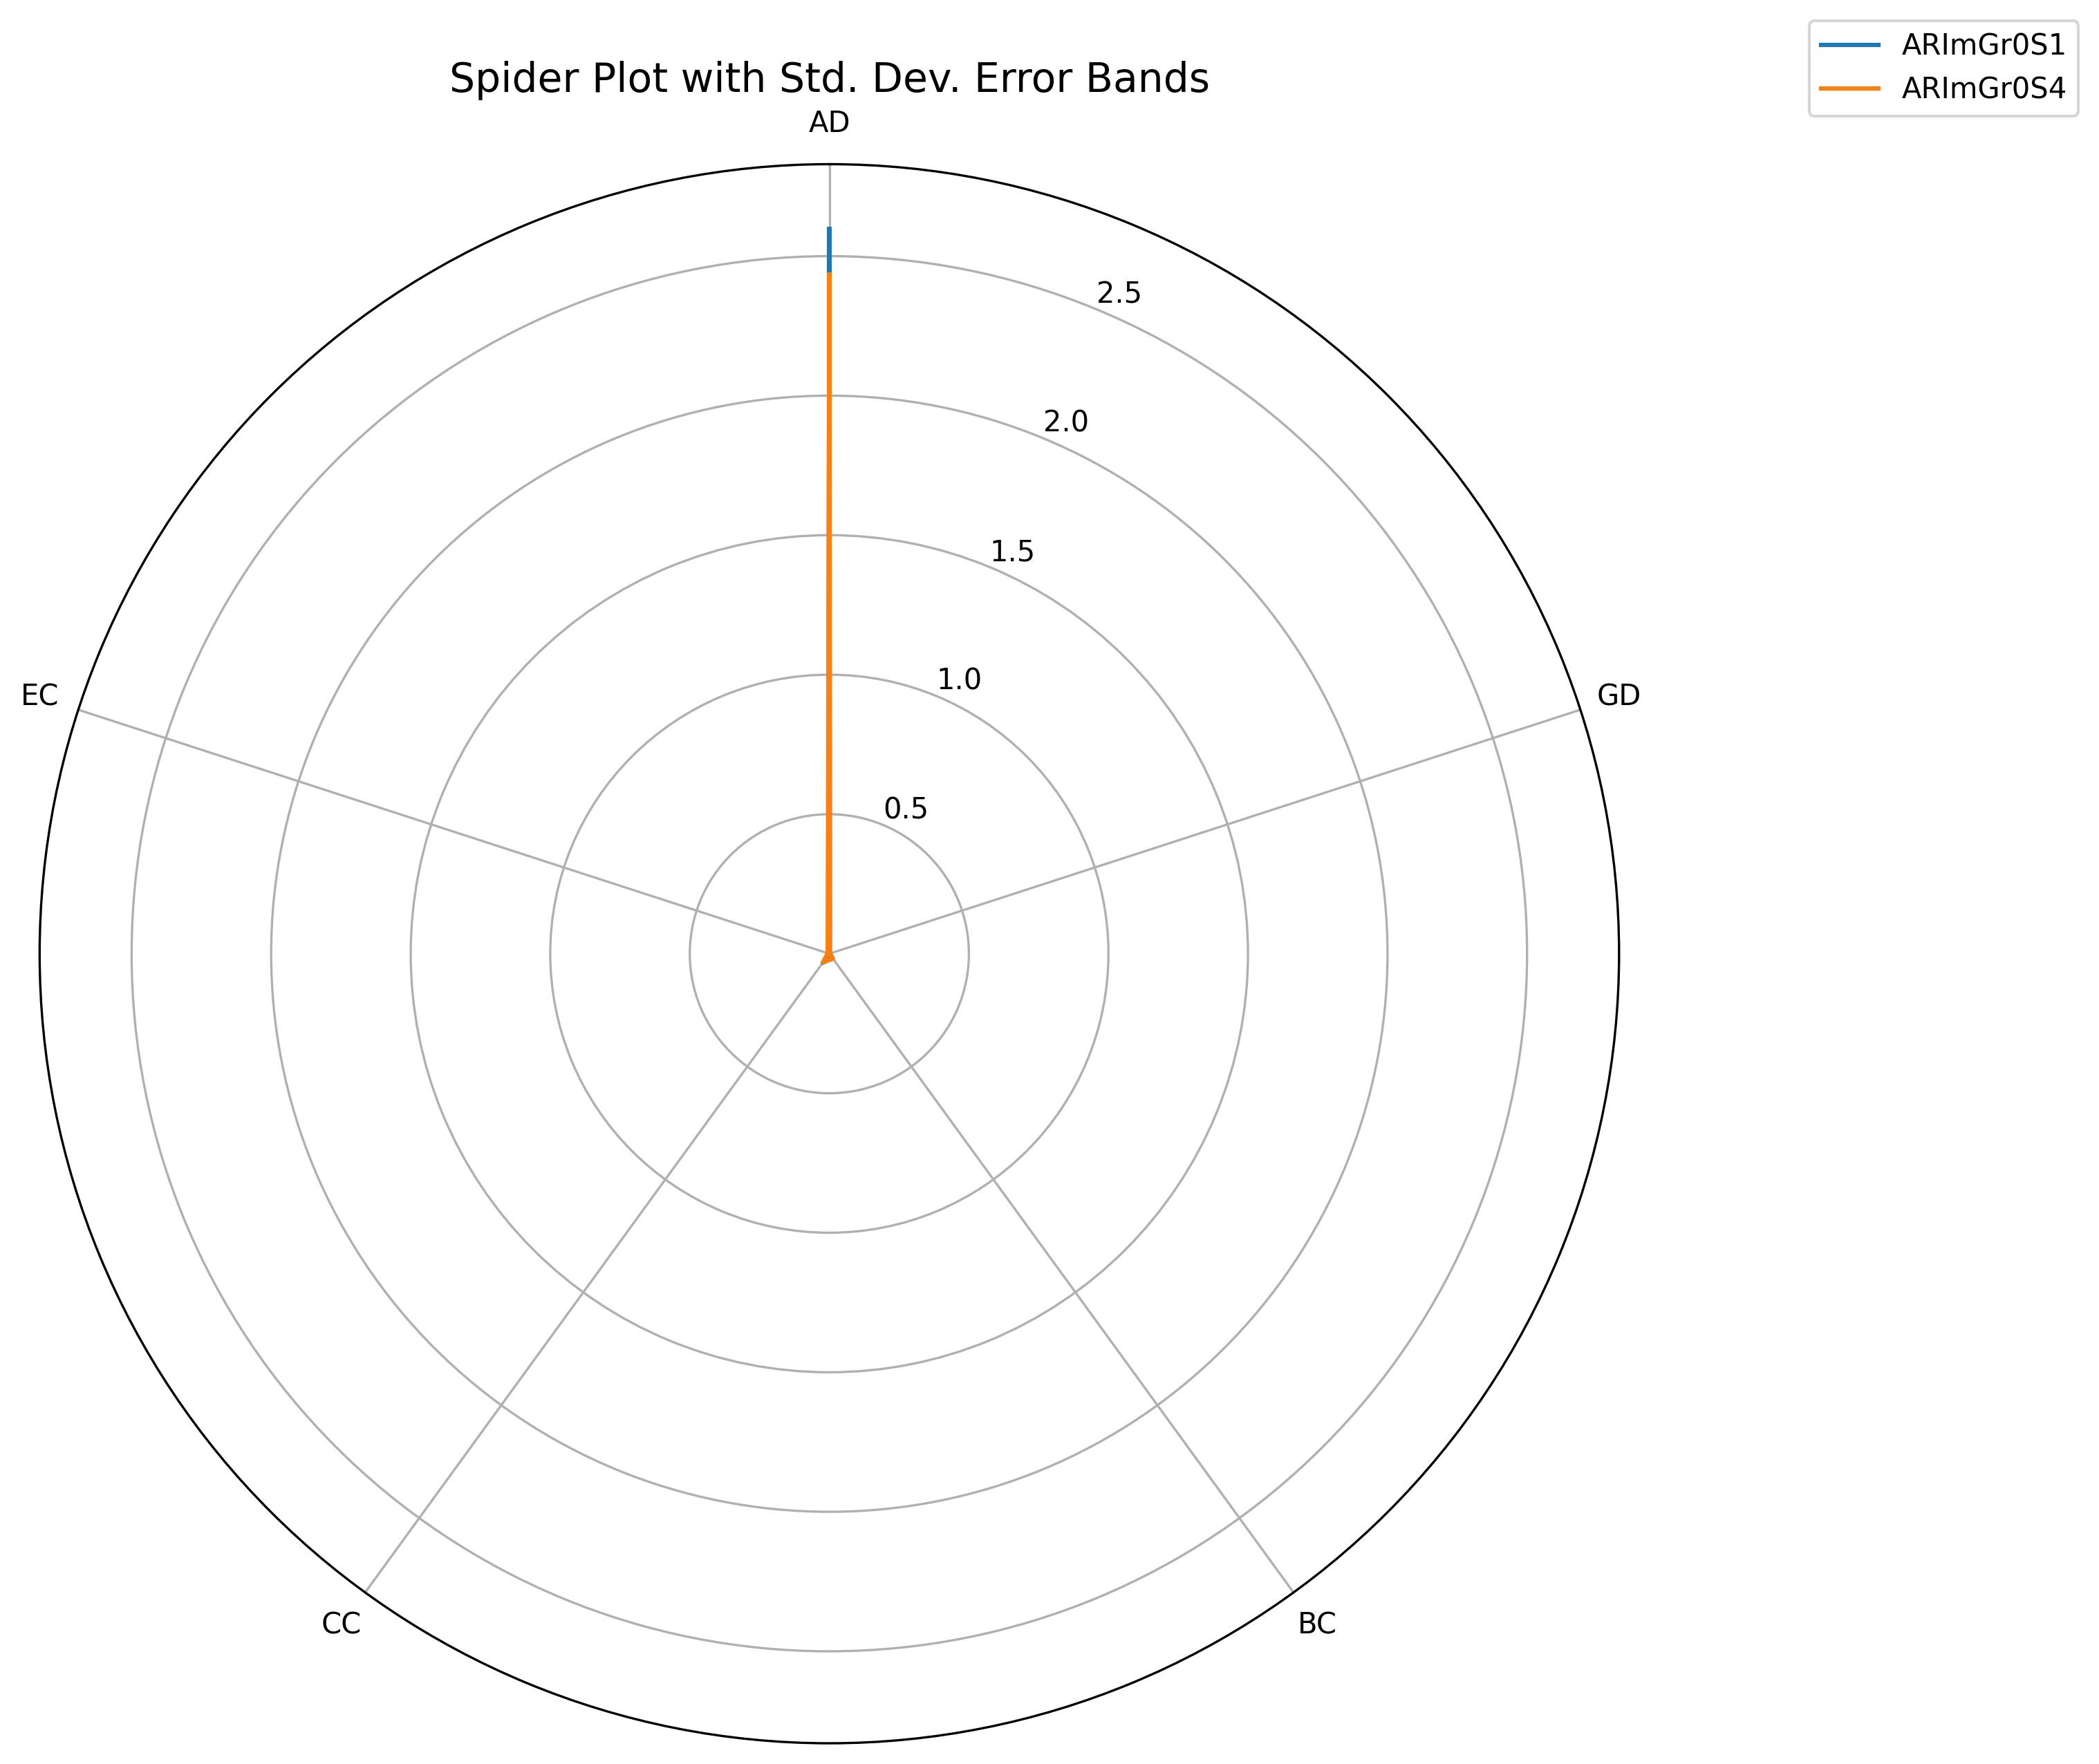

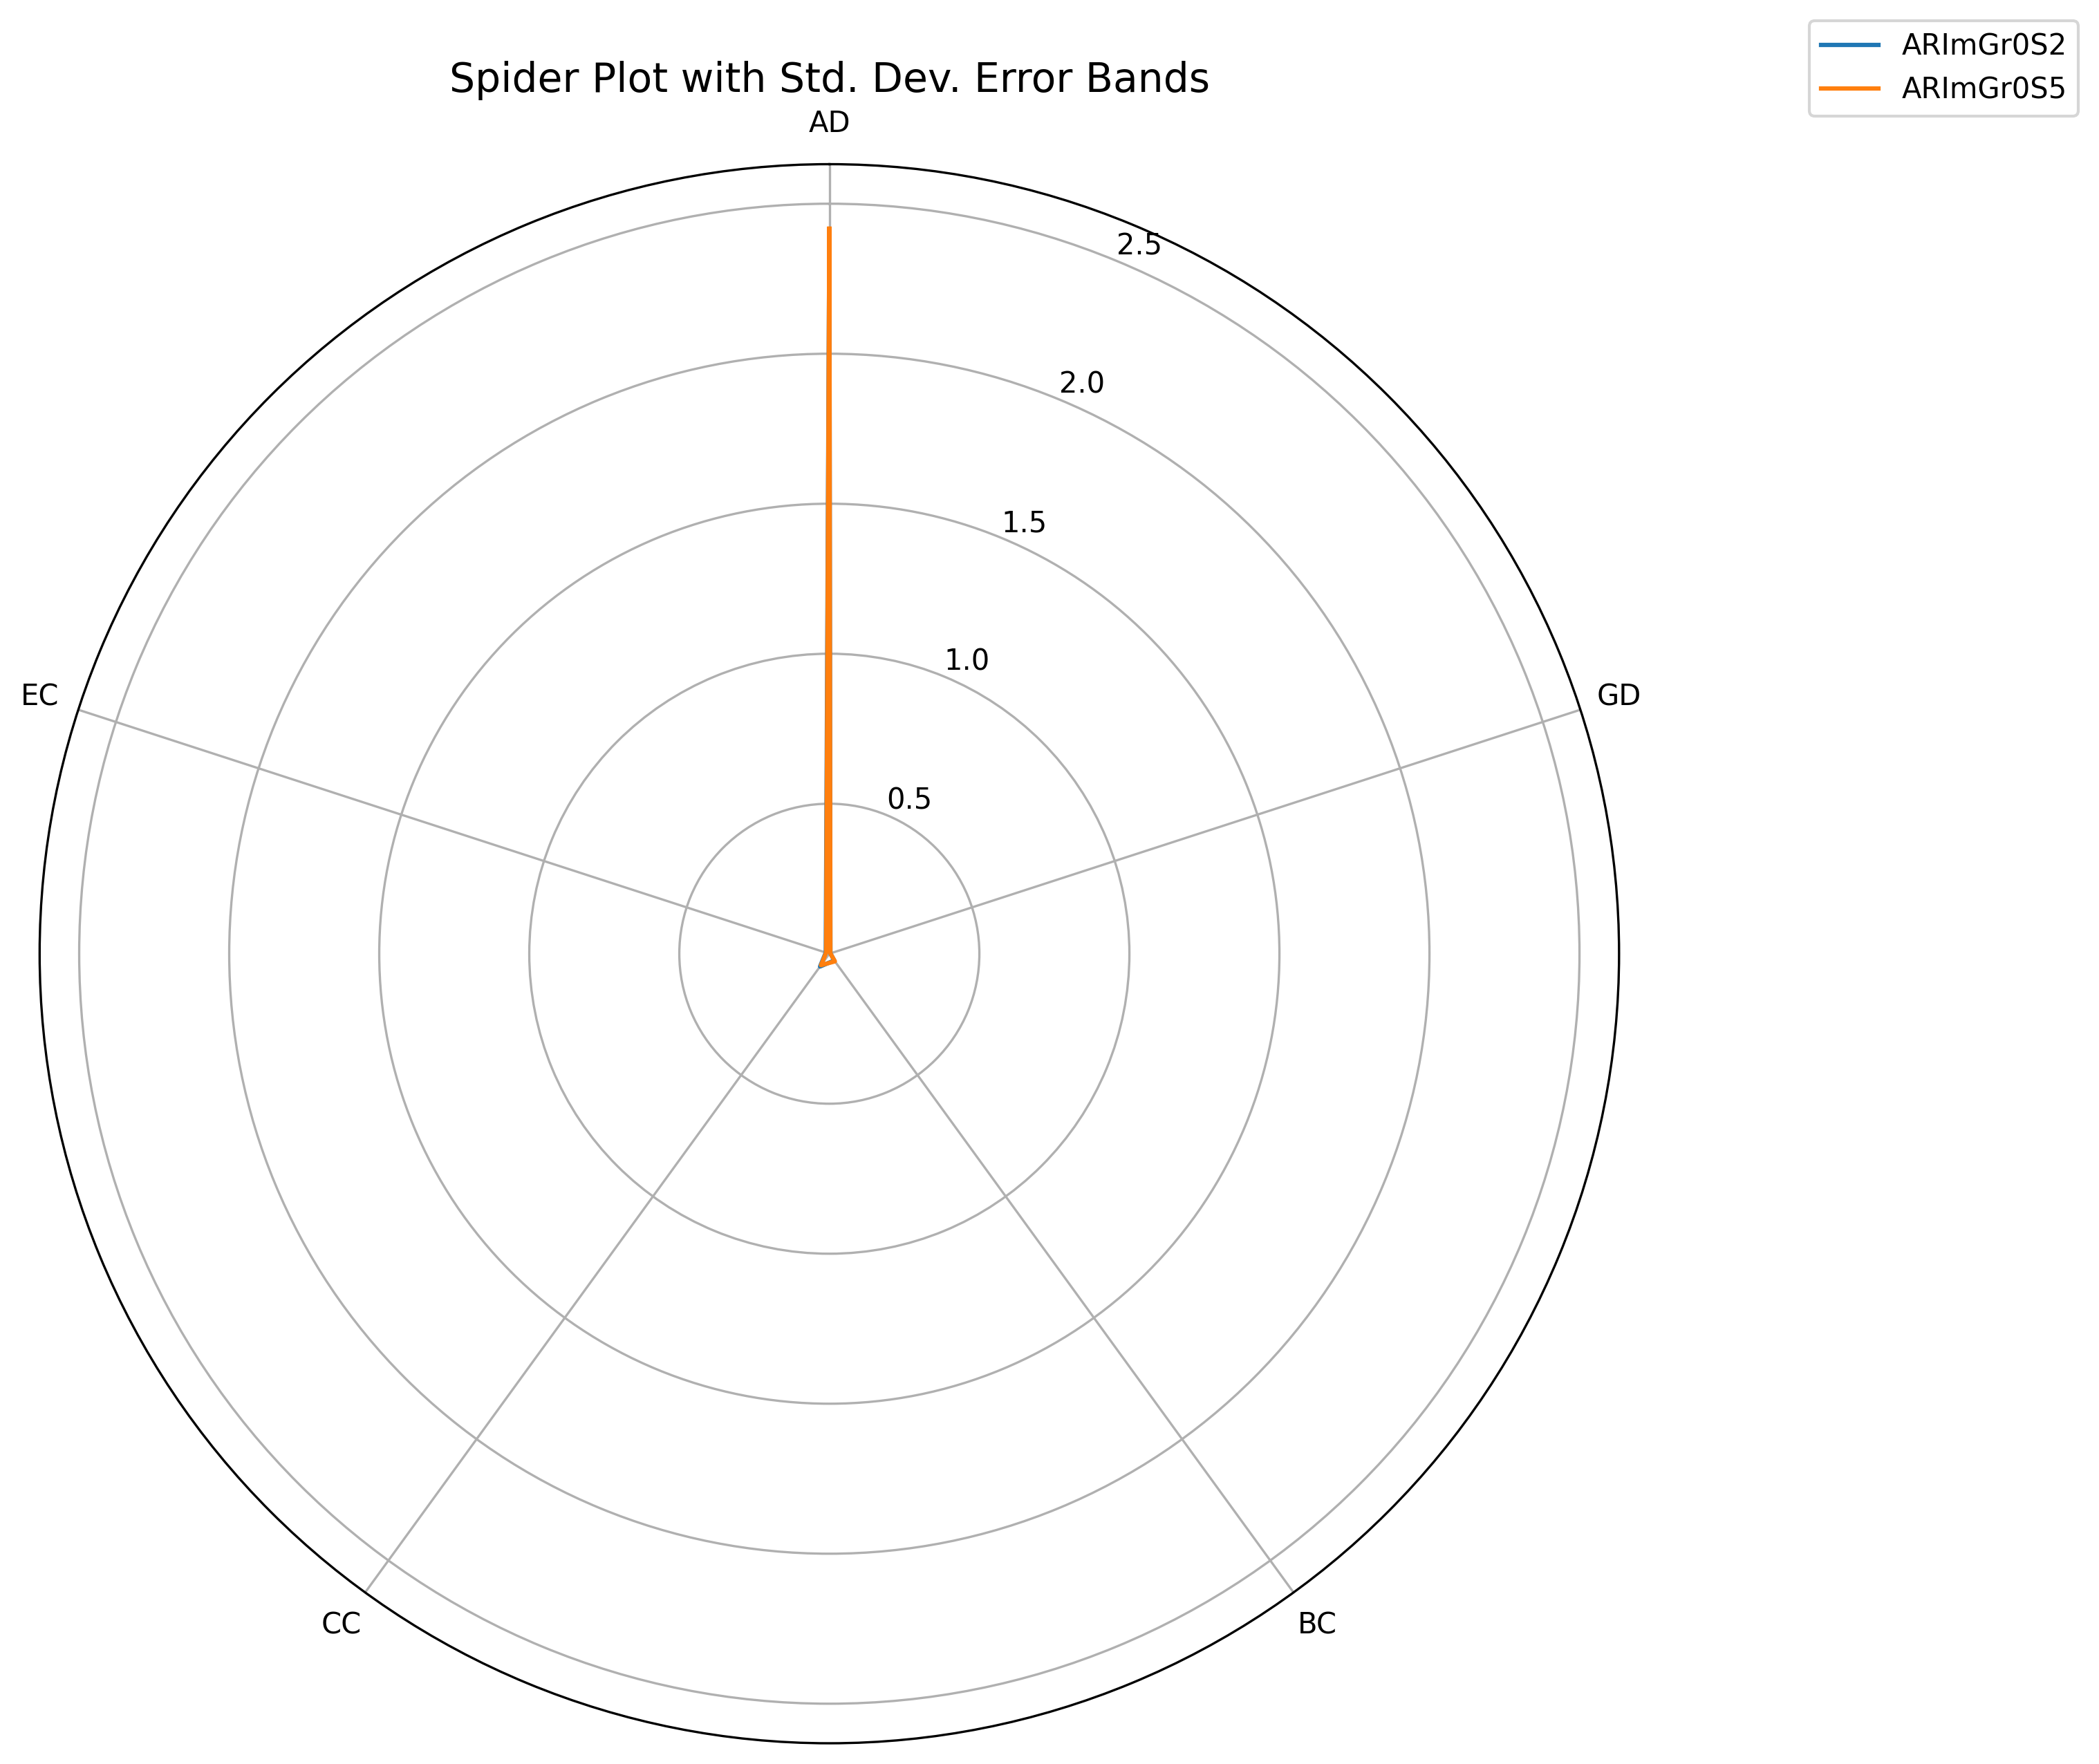

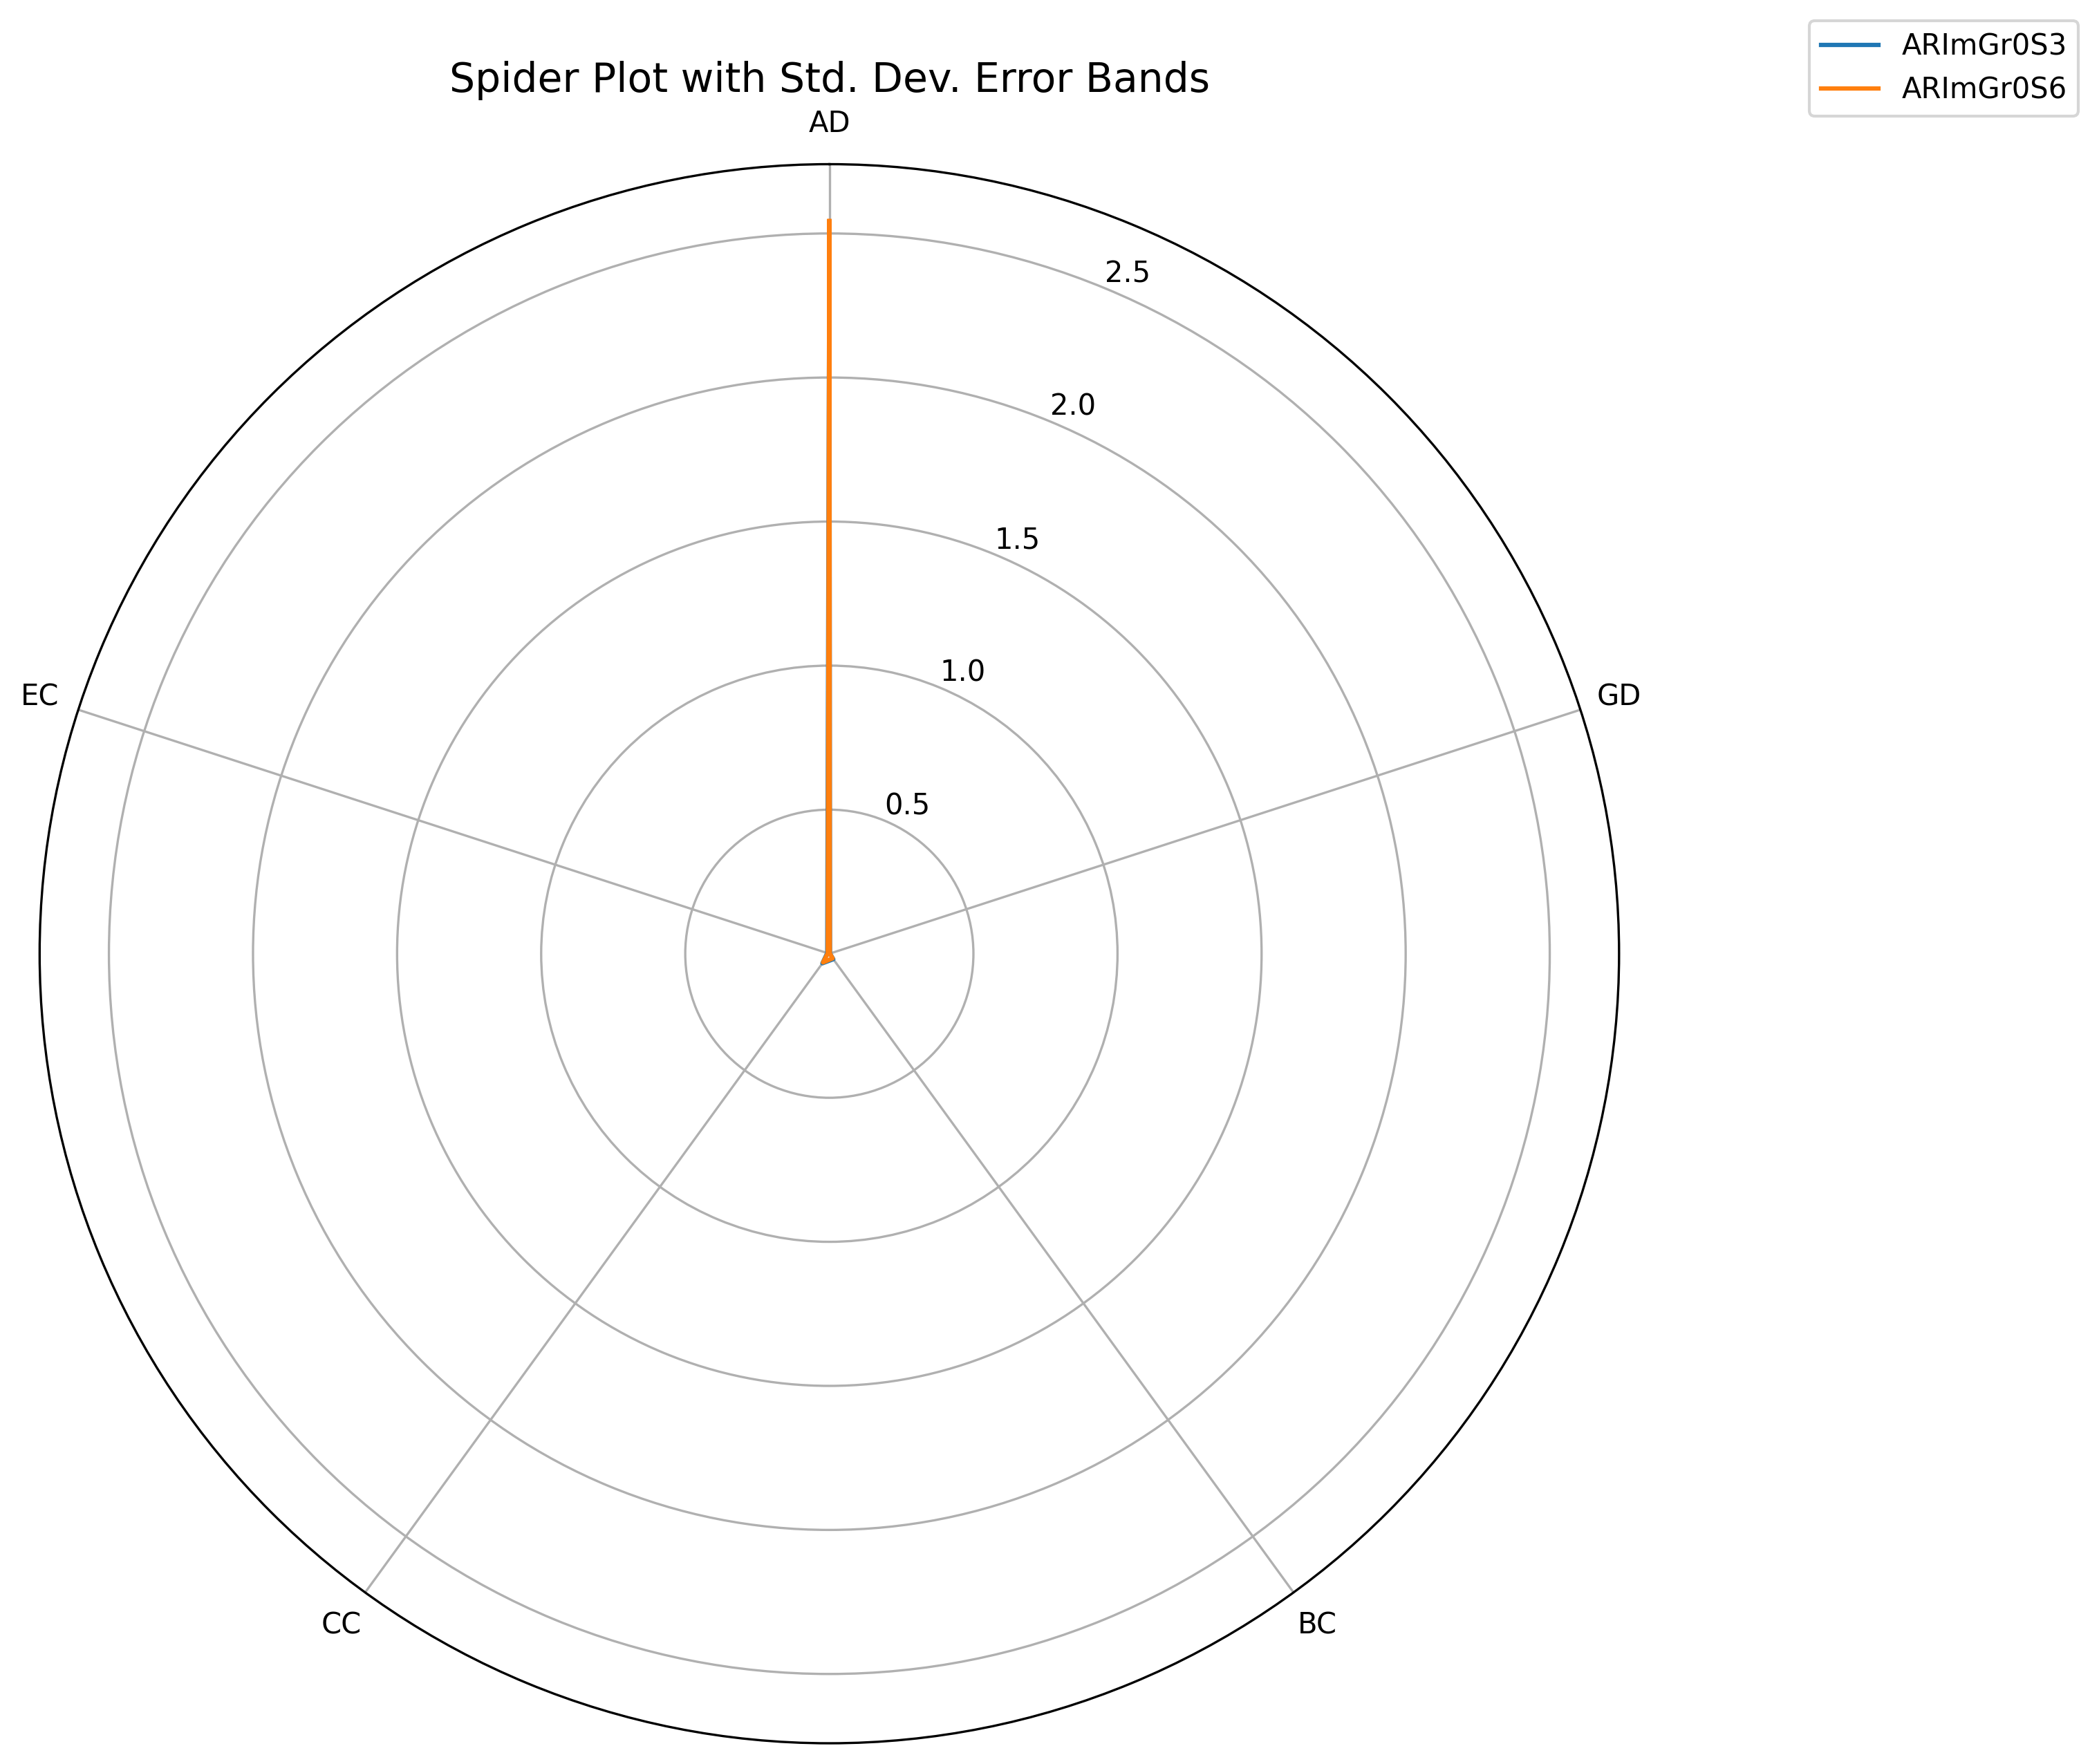

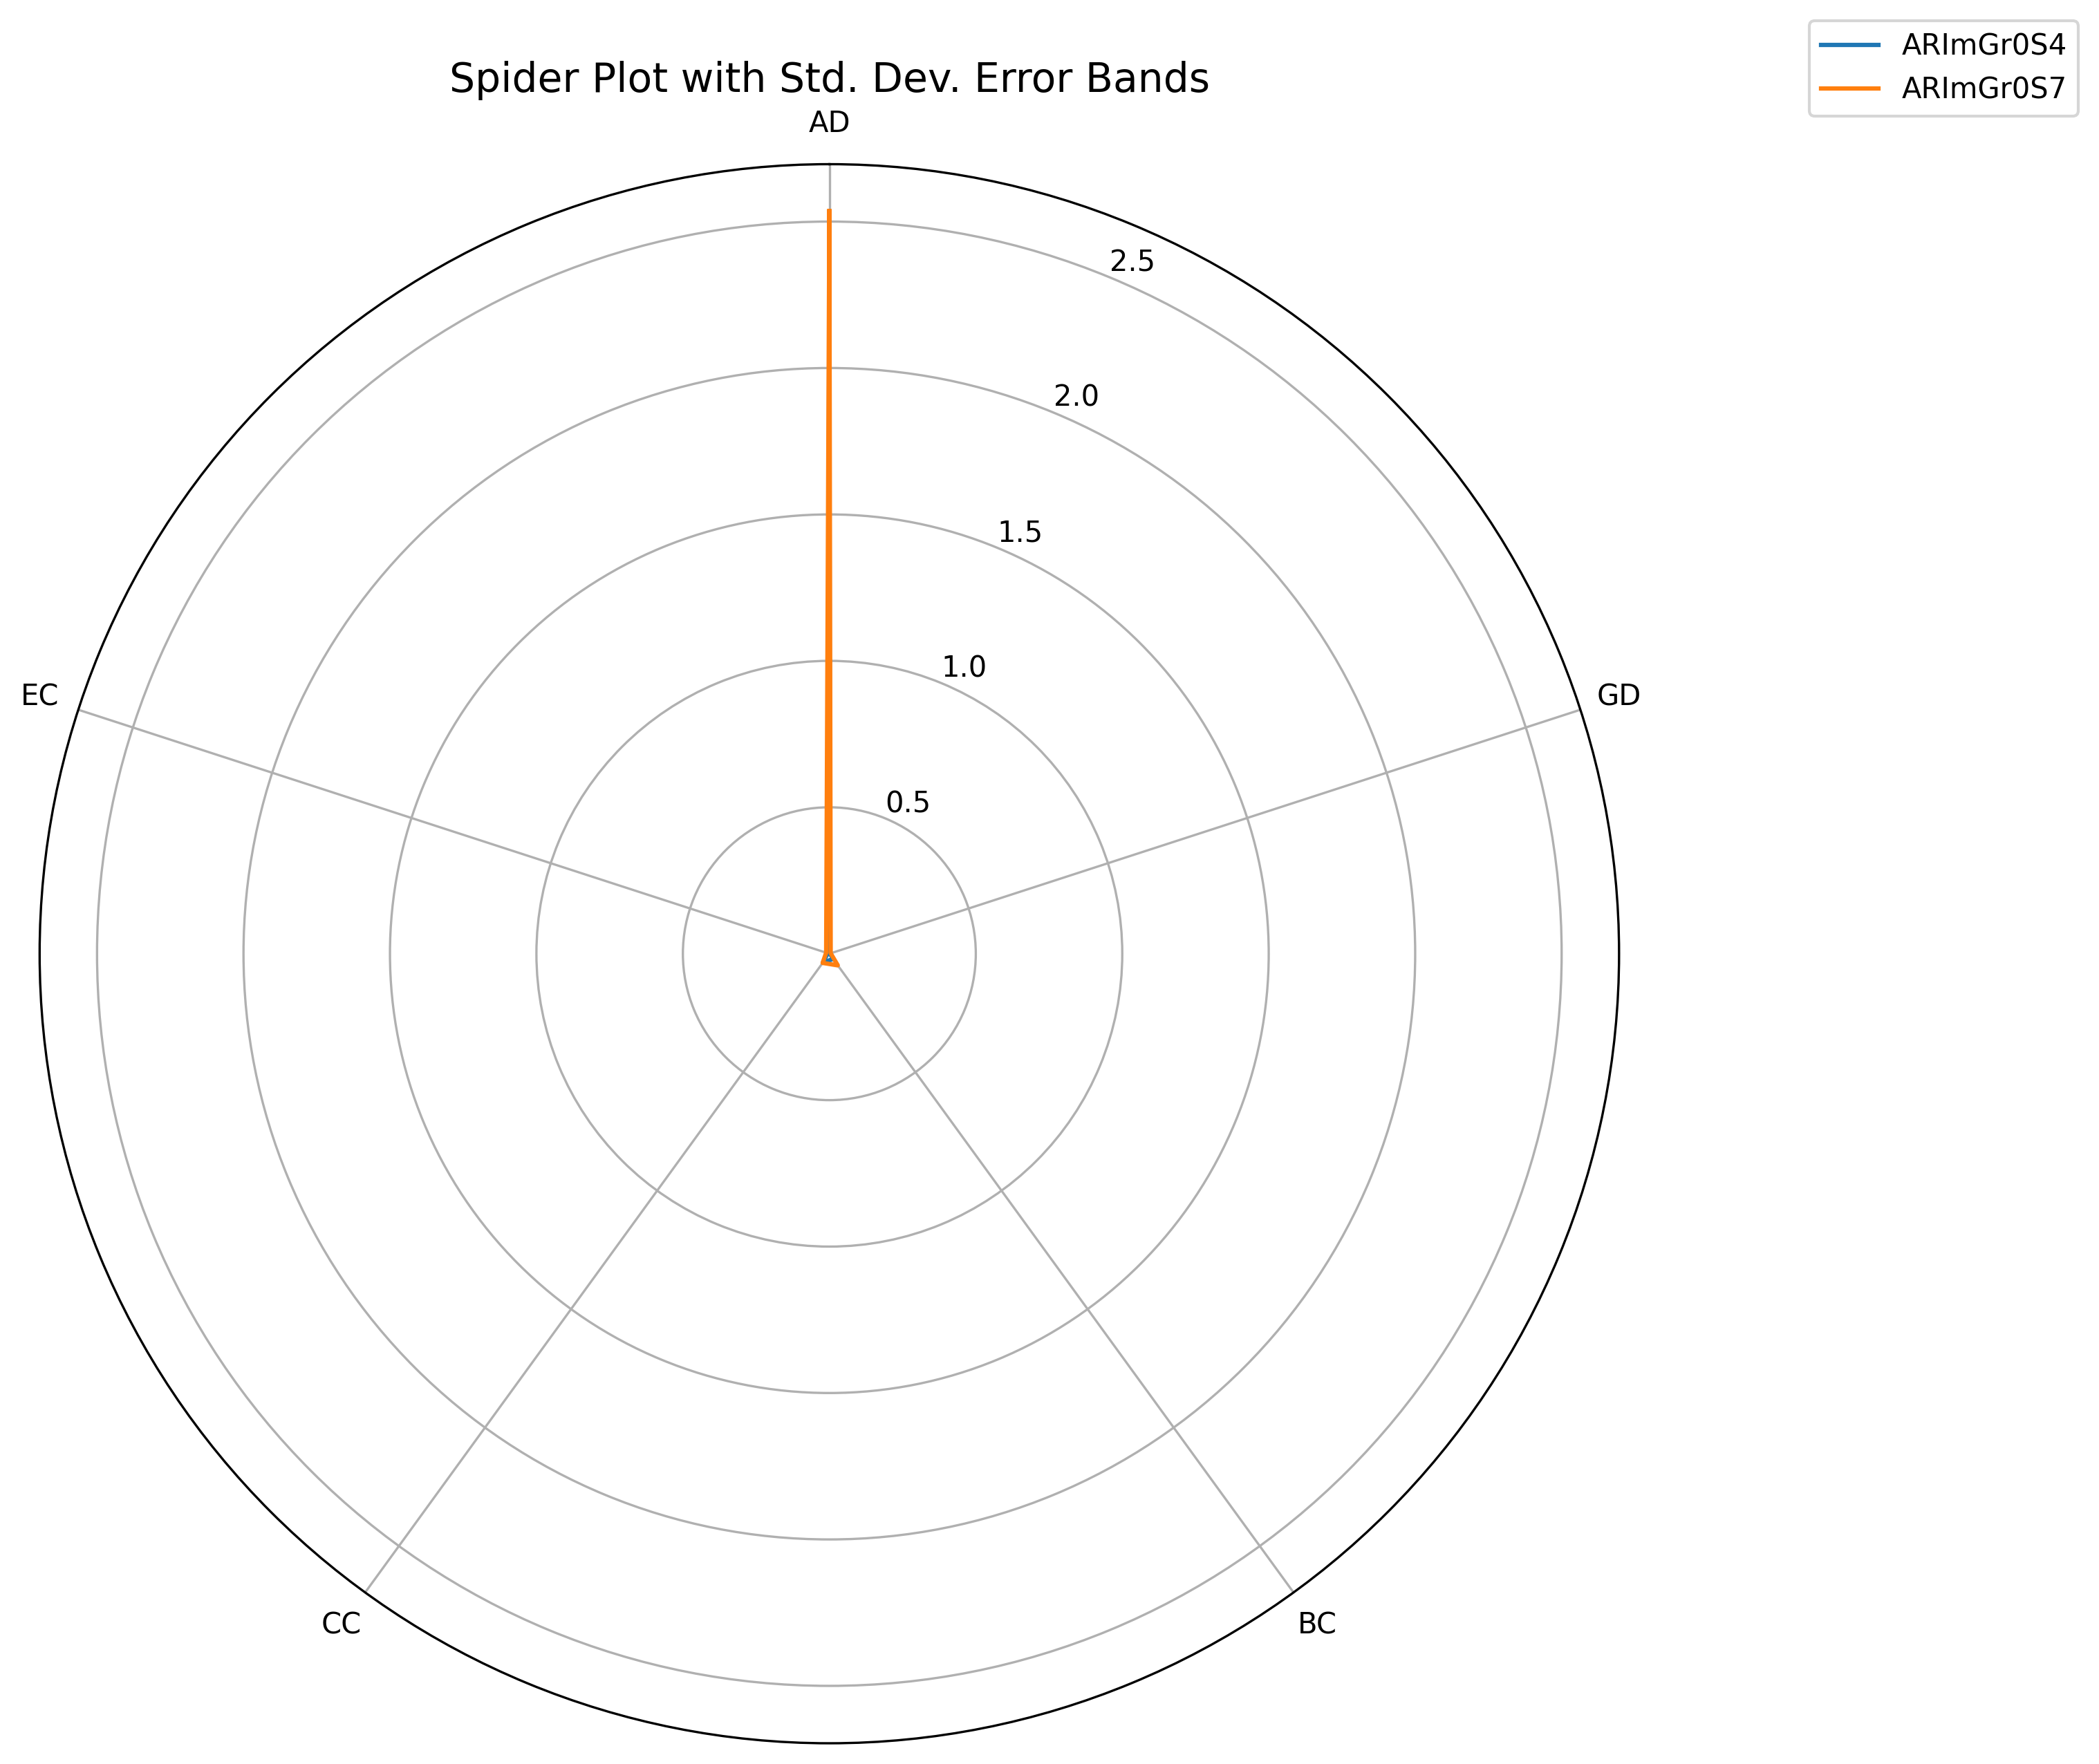

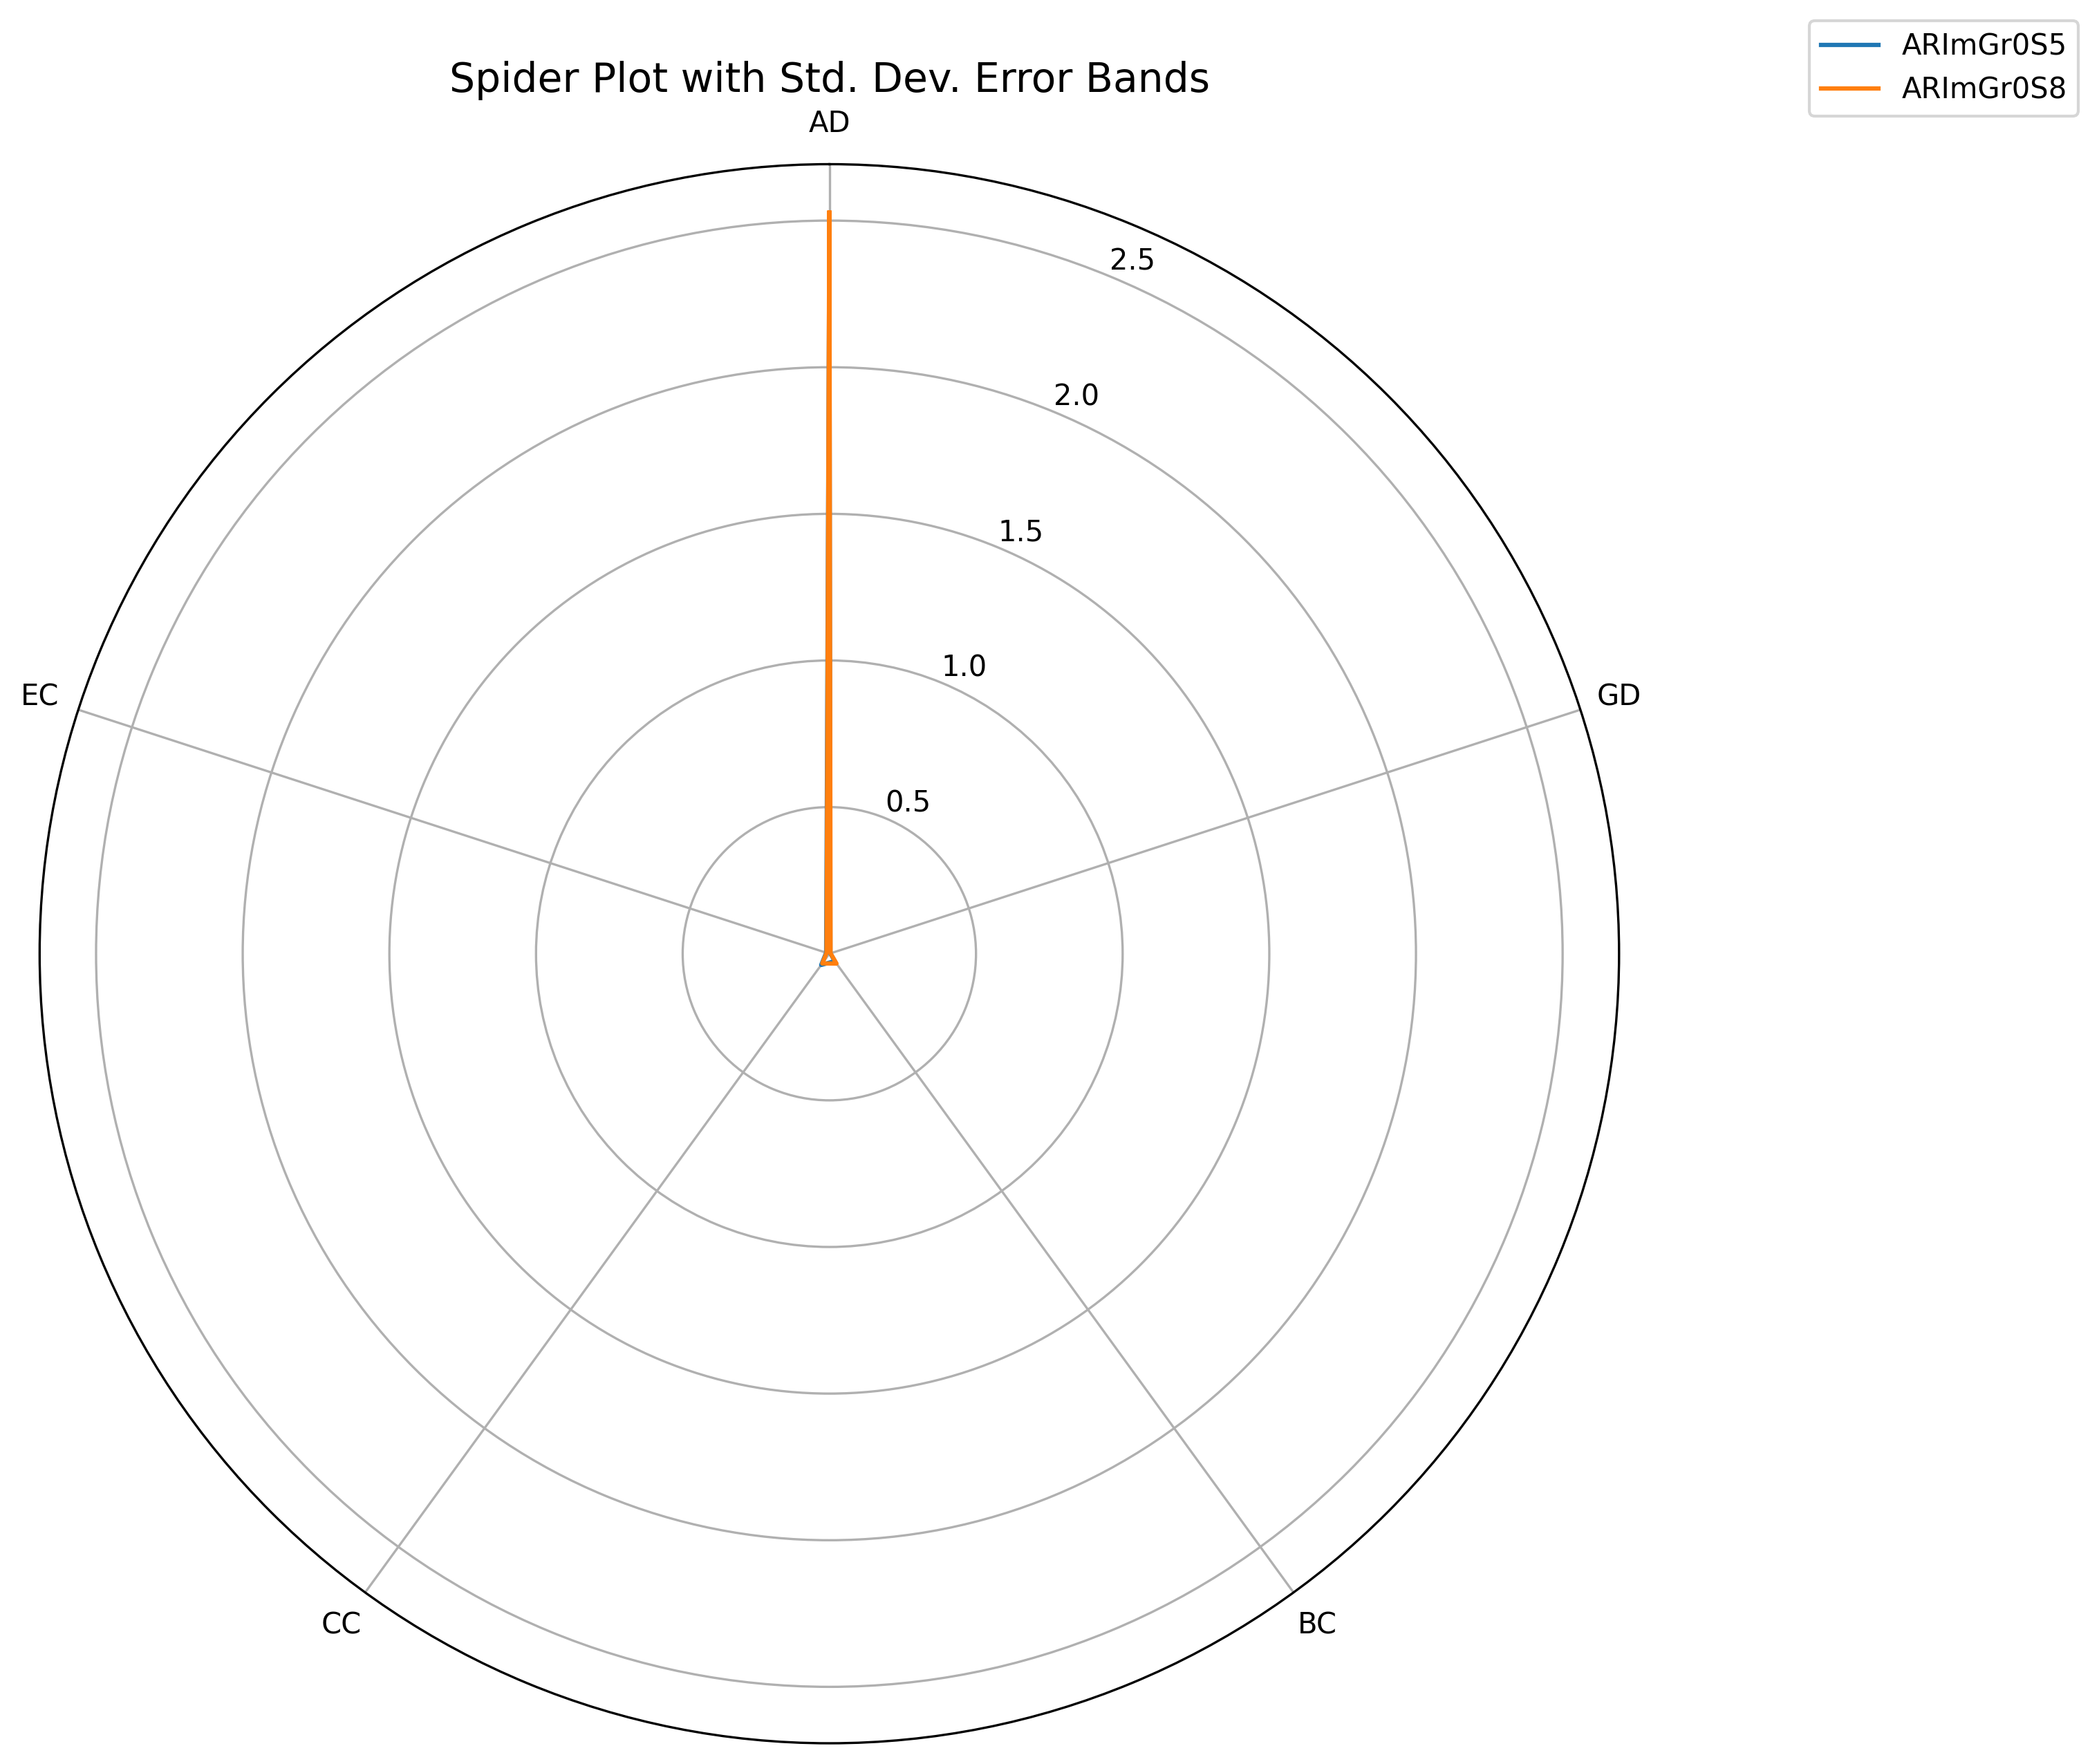

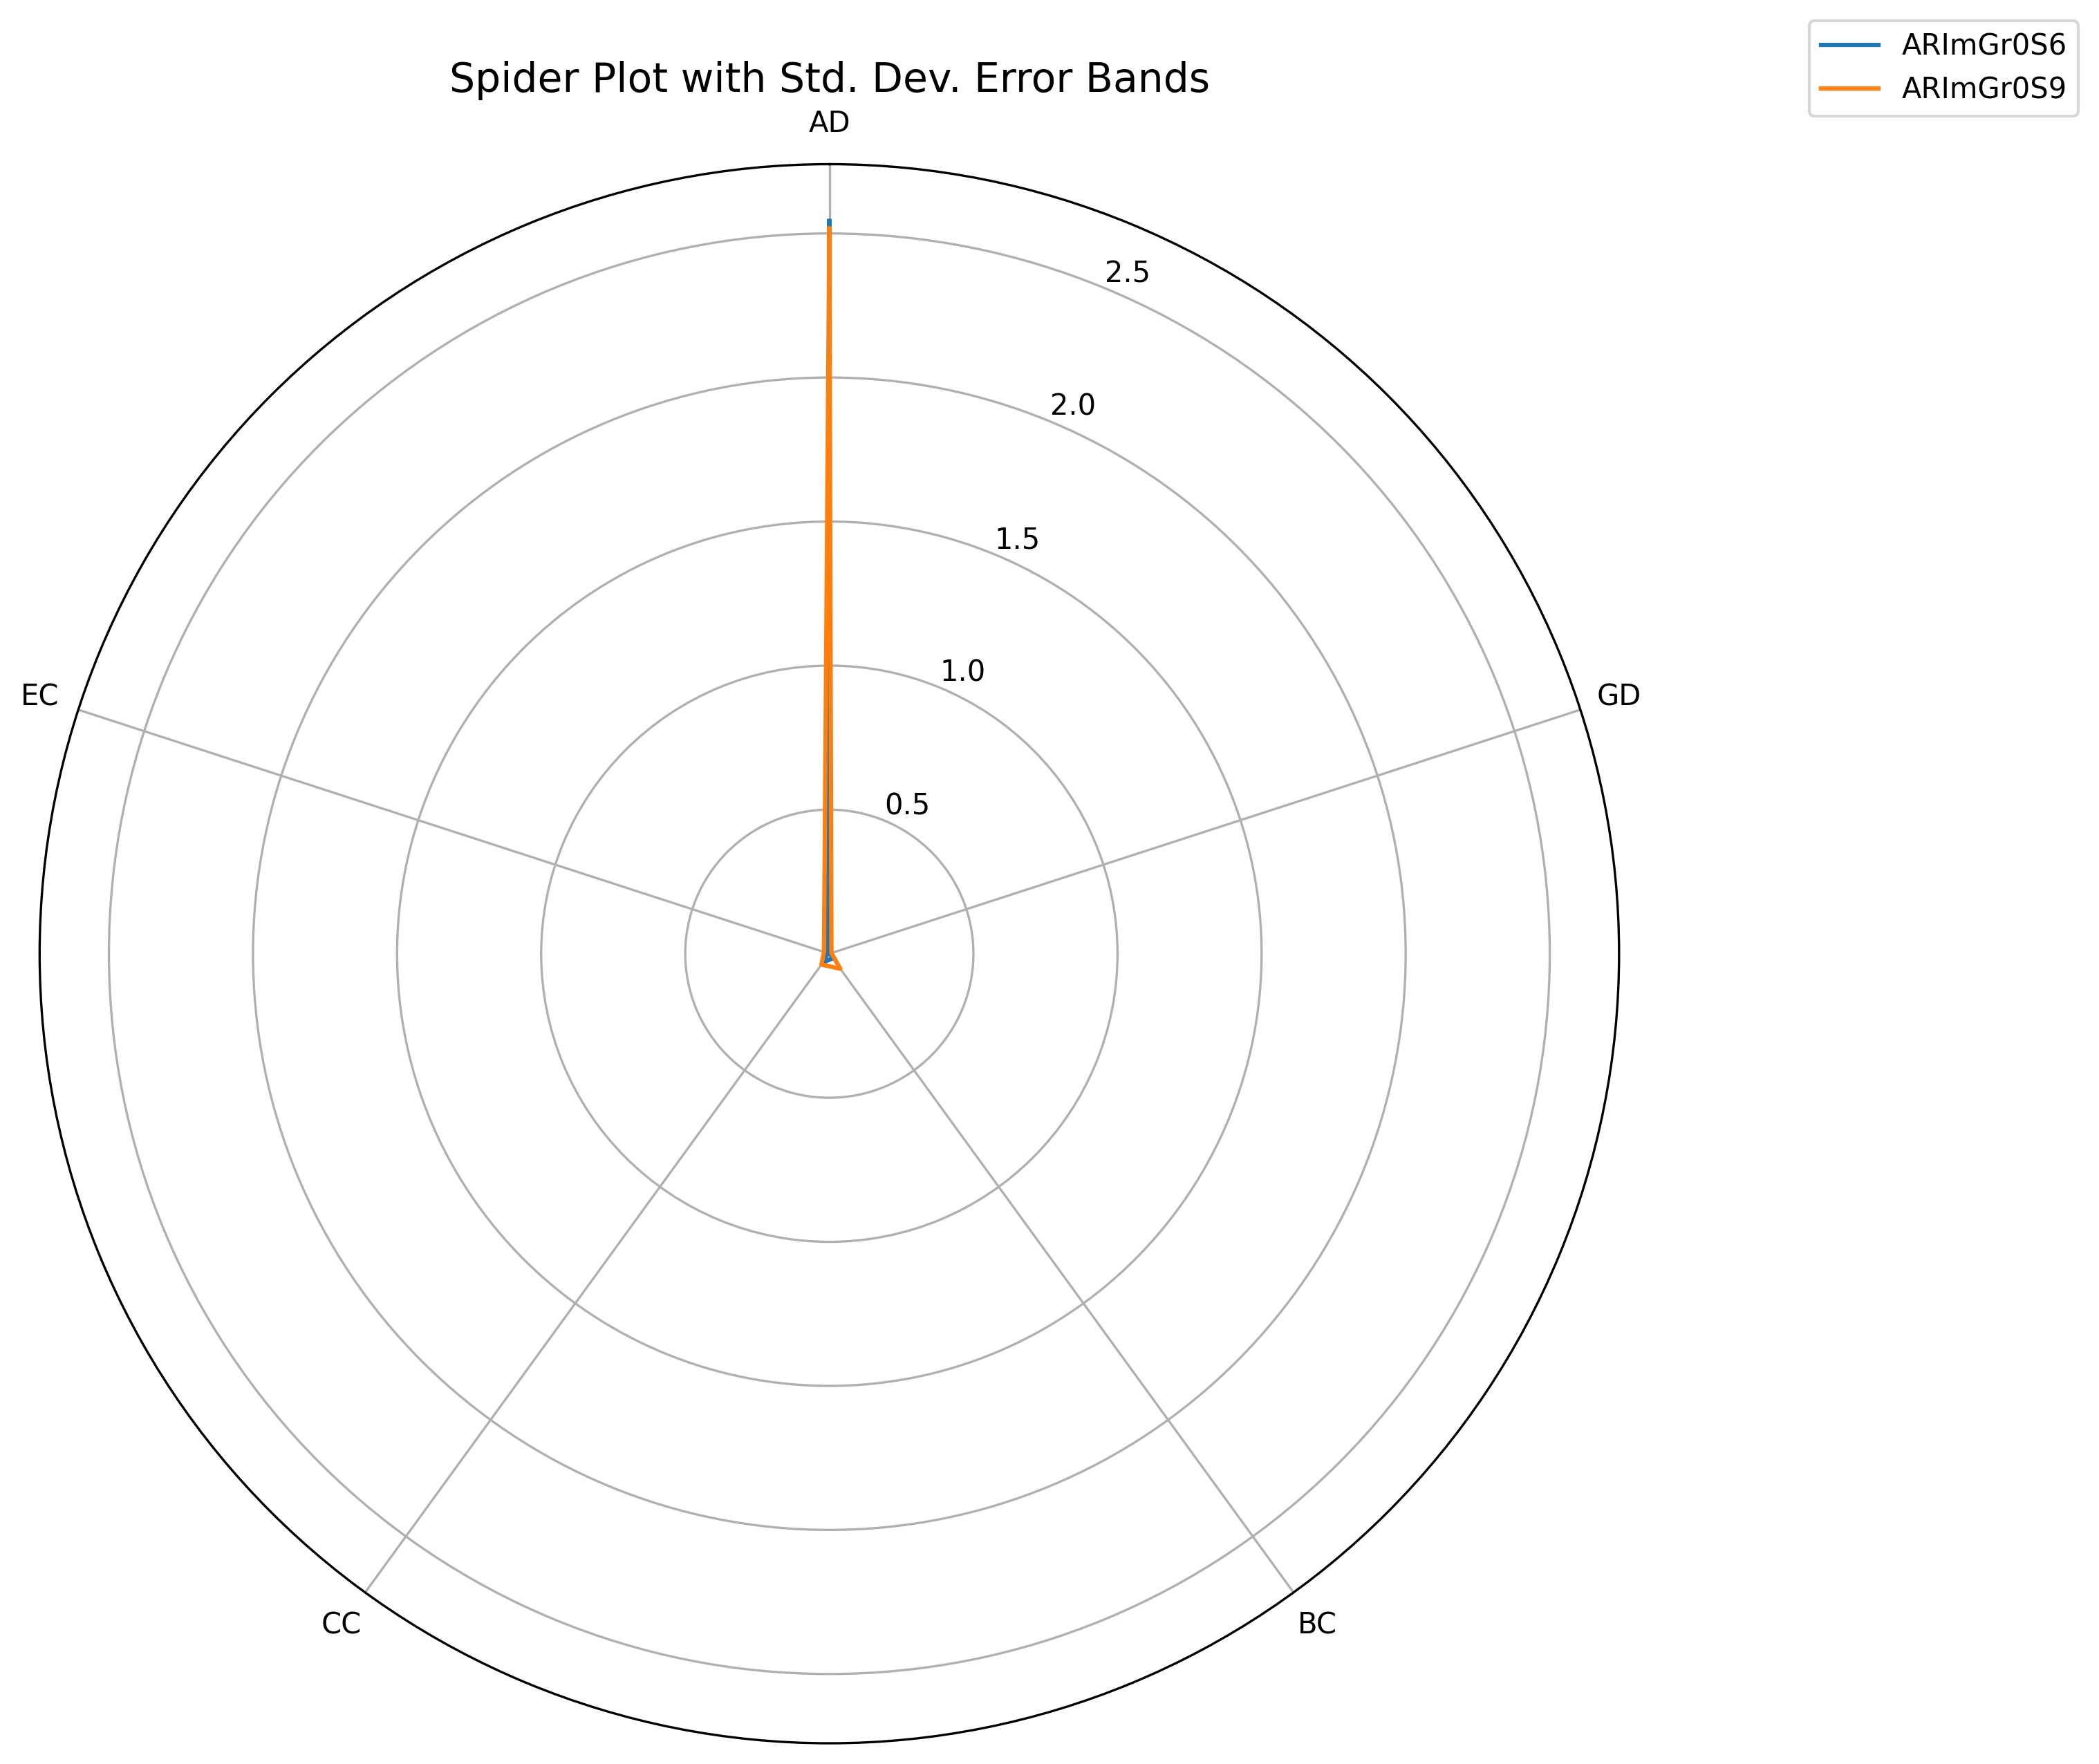

In [12]:
"""
Spider Plot: S1-S4
"""

for item in lst_compare:
    df_sgt = pd.concat([all_avg_dfs[item[0]], all_avg_dfs[item[1]]], ignore_index=True)
    plt_fig = sgt_spider_plot(df_sgt, item, parameters, value_cols=val_cols)
    plt_figs.append(plt_fig)

In [13]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)